In [1]:
using BSON, Dates, DelimitedFiles, Downloads, CUDA, cuDNN, Flux, Printf, Plots, JLD2, LinearAlgebra
using Flux.Zygote
include("utils.jl")
include("neural.jl");

In [2]:
BSON.@load "model_HS.bson" model #load model

Converged (step: 246, ‖Δρ‖ = 6.0886145e-5 < 6.103515625e-5 = tolerance)


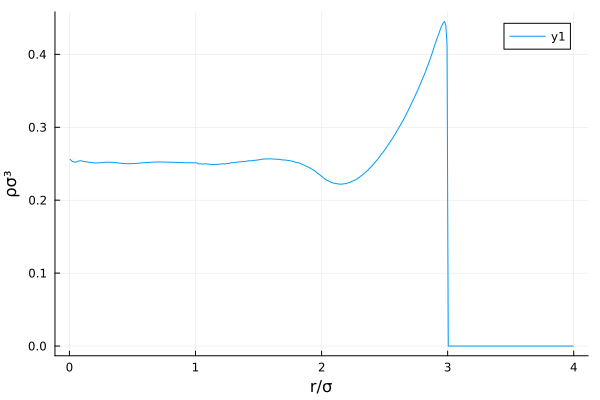

In [3]:
#radial density profile
Wall(r;d=3) = r > d ? Inf : 0 #hard walls
Solute(r;R=1) = r < R ? Inf : 0 #hard solute
Vextrad(r) = Wall(r) #external potential
µ = 0 #chemical potential
T = 1 #temperature
L = 4 #radius of the system
rs,ρ = minimize(L,µ,T,Vextrad,get_c1_neural_rad,model;scalewindows = scale_windows)#DFT minimization
plot(rs,ρ,xlabel = "r/σ", ylabel = "ρσ³") #radial density profile, see Fig. 3

┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(402 => 256, softplus)  # 103_168 parameters
│   summary(x) = "402×500 CuArray{Float64, 2, CUDA.DeviceMemory}"
└ @ Flux ~/.julia/packages/Flux/DZYiO/src/layers/stateless.jl:60


Converged (step: 220, ‖Δρ‖ = 6.0886145e-5 < 6.103515625e-5 = tolerance)


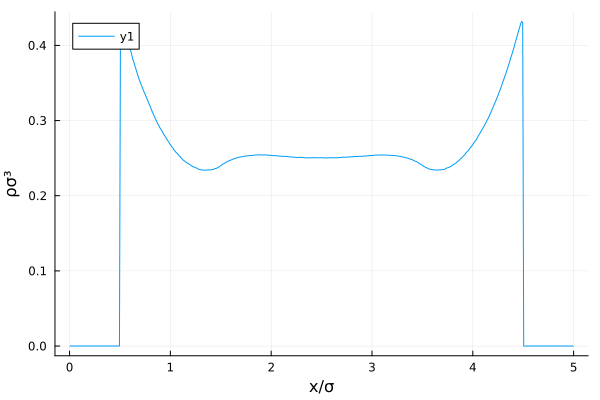

In [4]:
#planar density profile
HW(x) = x < 0.5 || x > 4.5 ? Inf : 0
L = 5
xs, ρ_plan = minimize_plan(L, μ, T, HW, xs -> get_c1_neural_plan(model)) #DFT minimization
plot(xs,ρ_plan,xlabel = "x/σ", ylabel = "ρσ³")#planar density profile

## Solve radial Ornstein-Zernike equation

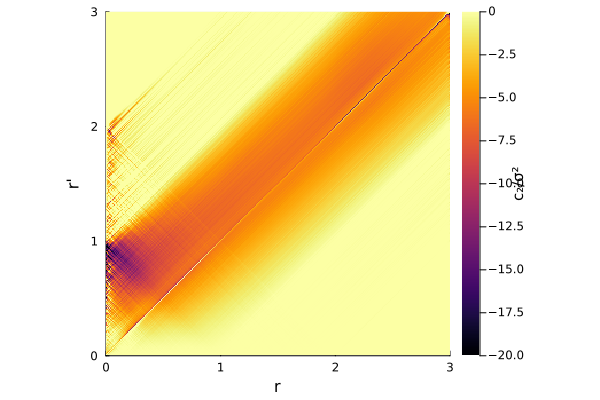

In [5]:
c2 = get_c2_from_ρ(ρ,rs,model)#automatic differentition, Eq. (18), (19)
allxc2,allc2 = construct_c2(c2)
rr,rp,c2mat = construct_c2mat(allxc2,allc2);
heatmap(rr, rp,c2mat,clim = (-20,0), aspect_ratio=1, colorbar_title  = "c₂/σ²",xlims=(0, 3),ylims = (0,3),xlabel = "r", ylabel = "r'")

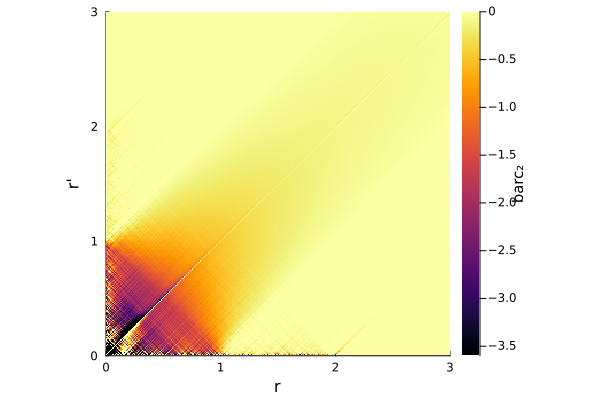

In [6]:
barc2 = c2mat  ./ (4*π* rp.^2) #symmetric version of c₂, Eq. (15)
heatmap(rr, rp,barc2,clim = (-3.6,0), aspect_ratio=1, colorbar_title  = "barc₂",xlims=(0, 3),ylims = (0,3),xlabel = "r", ylabel = "r'")

┌ Warning: function written for ,simple' situations
└ @ Main ~/code/spherical-neural/HS/utils.jl:58


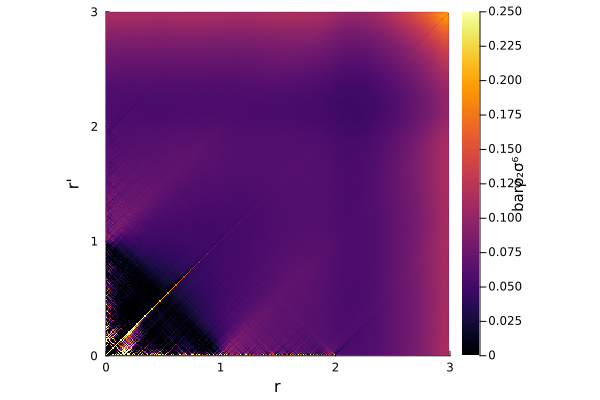

In [7]:
r,ρ2 = solve_OZ4ρ2(barc2,ρ) #Eq. (26), (27)
heatmap(r, r,ρ2,clim= (0,0.25),aspect_ratio=1,colorbar_title  = "barρ₂σ⁶",xlims=(0, 3),ylims=(0,3),xlabel = "r", ylabel = "r'")